# UMAP con embeddings + Clustering con HDBSCAN

In [ ]:
#pip install umap-learn hdbscan matplotlib seaborn

In [1]:
import torch
import numpy as np
import pandas as pd
import umap
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

In [2]:
tqdm.pandas()

# Carica dataset
features_path = "/data-lachesis/common/propp/DeniseAtzori/book_jeunesse_features.pt"
loaded = torch.load(features_path)
df = pd.DataFrame(loaded)

# Per comodità, useremo tutti i personaggi disponibili
print(f"Numero di personaggi totali: {len(df)}")

Numero di personaggi totali: 600


## Preparazione embeddings

In [3]:
def mean_concat_embeddings(row):
    agent = row['agent_embeddings'].mean(dim=0).numpy() if len(row['agent_embeddings']) > 0 else np.zeros(row['agent_embeddings'].shape[1])
    patient = row['patient_embeddings'].mean(dim=0).numpy() if len(row['patient_embeddings']) > 0 else np.zeros(row['patient_embeddings'].shape[1])
    mod = row['mod_embeddings'].mean(dim=0).numpy() if len(row['mod_embeddings']) > 0 else np.zeros(row['mod_embeddings'].shape[1])
    pos = row['pos_embeddings'].mean(dim=0).numpy() if len(row['pos_embeddings']) > 0 else np.zeros(row['pos_embeddings'].shape[1])
    return np.concatenate([agent, patient, mod, pos])

X = np.vstack(df.progress_apply(mean_concat_embeddings, axis=1))

  0%|          | 0/600 [00:00<?, ?it/s]

## Riduzione dimensionale con UMAP

In [4]:
# Riduzione dimensionale in 2D
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
X_umap = umap_reducer.fit_transform(X)

print("Shape dopo UMAP:", X_umap.shape)

/data-lachesis/common/propp/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape dopo UMAP: (600, 2)


## Clustering con HDBSCAN

In [5]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean')
clusters = clusterer.fit_predict(X_umap)

print("Numero di cluster trovati:", len(set(clusters)) - (1 if -1 in clusters else 0))
df['cluster'] = clusters

Numero di cluster trovati: 3


## Visualizzazione

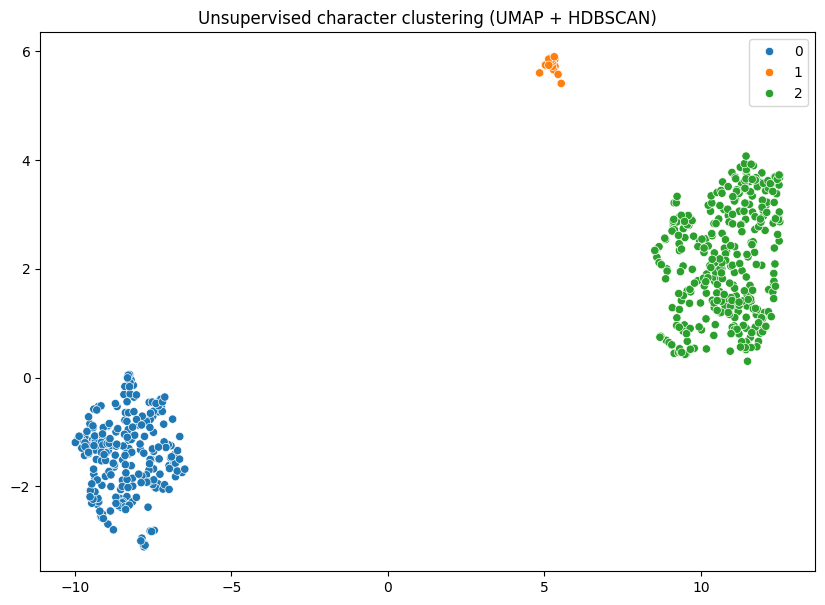

In [6]:
plt.figure(figsize=(10,7))
palette = sns.color_palette("tab10", n_colors=len(set(clusters)))
sns.scatterplot(
    x=X_umap[:,0], y=X_umap[:,1],
    hue=clusters,
    palette=palette,
    legend='full'
)
plt.title("Unsupervised character clustering (UMAP + HDBSCAN)")
plt.show()

## Mappa interattiva

In [7]:
import torch
import numpy as np
import pandas as pd
import umap
import hdbscan
from tqdm.auto import tqdm
import plotly.express as px

tqdm.pandas()

In [8]:
# Carica dataset
features_path = "/data-lachesis/common/propp/DeniseAtzori/book_jeunesse_features.pt"
loaded = torch.load(features_path)
df = pd.DataFrame(loaded)
print(f"Numero di personaggi totali: {len(df)}")

Numero di personaggi totali: 600


In [9]:
# Filtra solo label 0 e 1
df = df[df['type'].isin([0, 1])].reset_index(drop=True)
print(f"Numero di personaggi filtrati: {len(df)}")

Numero di personaggi filtrati: 546


In [10]:
# Calcolo embeddings concatenati (agent/patient/mod/pos)
def mean_concat_embeddings(row):
    agent = row['agent_embeddings'].mean(dim=0).numpy() if len(row['agent_embeddings']) > 0 else np.zeros(row['agent_embeddings'].shape[1])
    patient = row['patient_embeddings'].mean(dim=0).numpy() if len(row['patient_embeddings']) > 0 else np.zeros(row['patient_embeddings'].shape[1])
    mod = row['mod_embeddings'].mean(dim=0).numpy() if len(row['mod_embeddings']) > 0 else np.zeros(row['mod_embeddings'].shape[1])
    pos = row['pos_embeddings'].mean(dim=0).numpy() if len(row['pos_embeddings']) > 0 else np.zeros(row['pos_embeddings'].shape[1])
    return np.concatenate([agent, patient, mod, pos])

X = np.vstack(df.progress_apply(mean_concat_embeddings, axis=1))

  0%|          | 0/546 [00:00<?, ?it/s]

In [11]:
# UMAP 3D
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', n_components=3, random_state=42)
X_umap = umap_reducer.fit_transform(X)

/data-lachesis/common/propp/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
# Clustering HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean')
clusters = clusterer.fit_predict(X_umap)
df['cluster'] = clusters

In [13]:
df.head()

,file_name,char_name,char_id,type,Gender,agent_lemmas,patient_lemmas,mod_lemmas,pos_lemmas,agent_embeddings,patient_embeddings,mod_embeddings,pos_embeddings,cluster
0,1833_Girardin-Delphine-de_Contes-d-une-vieille...,léon,0,1.0,0.0,"[venir, obtenir, aimer, sauter, mettre, aperce...","[récompenser, emmener, laisse, décider, suivre...","[ravir, volant, volant, volant, affreux, gros,...","[mère, ordinaire, incertitude, mère, course, i...","[[tensor(-0.2522), tensor(-0.2233), tensor(-0....","[[tensor(0.1801), tensor(-0.3205), tensor(-0.2...","[[tensor(-0.2756), tensor(0.4234), tensor(-0.0...","[[tensor(0.0378), tensor(-0.3824), tensor(-0.0...",1
1,1833_Girardin-Delphine-de_Contes-d-une-vieille...,zoé,1,1.0,1.0,"[repartir, lever, descendre, apercevoir, doute...","[séparer, aider, regarder, accabler, admirer, ...","[petit, effronté, coquet, petit, malheureux, p...","[face, caprice, robe, amie, mère, crainte, coq...","[[tensor(0.0616), tensor(-0.2516), tensor(-0.0...","[[tensor(0.1705), tensor(-0.2149), tensor(-0.3...","[[tensor(0.0626), tensor(-0.2282), tensor(-0.2...","[[tensor(-0.1416), tensor(0.1424), tensor(-0.3...",0
2,1833_Girardin-Delphine-de_Contes-d-une-vieille...,césaro,2,1.0,0.0,"[avoir, dire, aller, dire, lever, faire, écrie...","[rendre, écouter, corriger, fatiguer, prendre,...","[petit, fille, spirituel, petit, âgé, fier, fi...","[défaut, discours, père, langage, femme, père,...","[[tensor(-0.0889), tensor(-0.2208), tensor(-0....","[[tensor(0.5683), tensor(-0.0505), tensor(-0.4...","[[tensor(-0.1546), tensor(-0.4502), tensor(-0....","[[tensor(0.6686), tensor(-0.0990), tensor(0.00...",0
3,1833_Girardin-Delphine-de_Contes-d-une-vieille...,aglaure,3,1.0,1.0,"[faire, jouer, devenir, sentir, vouloir, espér...","[appeler, inviter, intimider, voir, environner...","[bonhomme, tout, ancien, ravir, étonné, ingrat...","[spéculation, camarade, habitude, ami, étable,...","[[tensor(-0.1492), tensor(-0.3598), tensor(-0....","[[tensor(-0.1114), tensor(0.1678), tensor(-0.2...","[[tensor(0.4053), tensor(0.0214), tensor(-0.14...","[[tensor(0.0398), tensor(0.1744), tensor(-0.73...",1
4,1835_Woillez-Catherine_Le-Robinson-des-demoise...,emma,0,1.0,1.0,"[voir, devoir, pouvoir, dire, acquérir, balbut...","[avoir, éloigner, destiner, reléguer, égayer, ...","[petit, innocent, tel, dernier, pauvre, seul, ...","[vie, présence, père, berceau, nourrice, besoi...","[[tensor(0.0704), tensor(-0.2040), tensor(0.12...","[[tensor(-0.2184), tensor(0.0933), tensor(0.09...","[[tensor(-0.3376), tensor(-0.2748), tensor(-0....","[[tensor(-0.5745), tensor(0.1942), tensor(0.06...",0


In [14]:
# Creiamo un DataFrame con le coordinate UMAP
df_umap = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_umap['char_name'] = df['char_name']
df_umap['file_name'] = df['file_name']
df_umap['type'] = df['type']
df_umap['Gender'] = df['Gender']
df_umap['cluster'] = df['cluster']

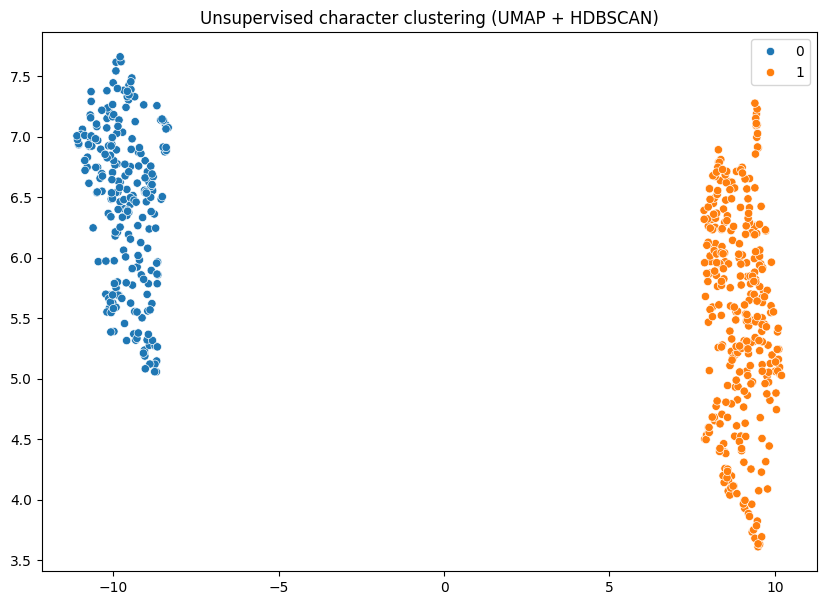

In [15]:
plt.figure(figsize=(10,7))
palette = sns.color_palette("tab10", n_colors=len(set(clusters)))
sns.scatterplot(
    x=X_umap[:,0], y=X_umap[:,1],
    hue=clusters,
    palette=palette,
    legend='full'
)
plt.title("Unsupervised character clustering (UMAP + HDBSCAN)")
plt.show()

In [16]:
# Visualizzazione 3D interattiva con Plotly
fig = px.scatter_3d(
    df_umap, x='UMAP1', y='UMAP2', z='UMAP3',
    color='type',  # puoi cambiare con 'label' per vedere adulti/bambini
    hover_data=['char_name', 'file_name', 'type', "Gender"],
    title="UMAP 3D + HDBSCAN Clustering dei personaggi"
)
fig.update_layout(width=900, height=700)
fig.show()

Riflessione: il tipo (adulto o bambino) non sembra influenzare significativamente i clusters

## Estrazione frequenze dei lemmi

estrarre tutti i lemmi agent/patient/mod/pos di un cluster e vedere quali compaiono più spesso:

In [56]:
cluster_id = 0 # ad esempio cluster 0
cluster_chars = df[df['cluster'] == cluster_id]

# tutti gli agent lemmas in questo cluster
agent_lemmas = sum(cluster_chars['mod_lemmas'].tolist(), [])
from collections import Counter
Counter(agent_lemmas).most_common(50)

[('petit', 2993),
 ('pauvre', 1897),
 ('jeune', 1642),
 ('cher', 1305),
 ('bon', 1043),
 ('vieux', 476),
 ('heureux', 464),
 ('sûr', 322),
 ('seul', 312),
 ('content', 271),
 ('joli', 233),
 ('malade', 217),
 ('bel', 208),
 ('malheureux', 201),
 ('grand', 201),
 ('charmant', 165),
 ('fille', 153),
 ('tout', 123),
 ('aimable', 114),
 ('pâle', 114),
 ('doux', 110),
 ('méchant', 105),
 ('gentil', 103),
 ('triste', 94),
 ('femme', 90),
 ('enfant', 88),
 ('excellent', 87),
 ('brave', 85),
 ('nouveau', 83),
 ('fier', 82),
 ('adoptif', 79),
 ('riche', 71),
 ('prêt', 71),
 ('sage', 71),
 ('chéri', 67),
 ('inquiet', 59),
 ('désolé', 57),
 ('fort', 57),
 ('digne', 56),
 ('gros', 55),
 ('fou', 55),
 ('aise', 55),
 ('rouge', 52),
 ('premier', 51),
 ('autre', 50),
 ('aîné', 50),
 ('mort', 49),
 ('généreux', 49),
 ('raisonnable', 47),
 ('faible', 46)]

### Confronto con le etichette

In [18]:
cluster_summary = cluster_chars['type'].value_counts(normalize=True)
print(cluster_summary)

type
0.0    0.5623
1.0    0.4377
Name: proportion, dtype: float64


## Estrazione nomi e libri dai clusters

In [19]:
# Otteniamo tutti i cluster unici (escluso -1 se HDBSCAN li mette come rumore)
clusters = sorted(df['cluster'].unique())
print("Cluster trovati:", clusters)

for clust_id in clusters:
    cluster_chars = df[df['cluster'] == clust_id]
    print(f"\n=== Cluster {clust_id} ({len(cluster_chars)} personaggi) ===")
    
    # Stampa char_name e file_name
    for name, file in zip(cluster_chars['char_name'], cluster_chars['file_name']):
        print(f"{name} - {file}")

Cluster trovati: [0, 1]

=== Cluster 0 (233 personaggi) ===
zoé - 1833_Girardin-Delphine-de_Contes-d-une-vieille-fille-a-ses-neveux
césaro - 1833_Girardin-Delphine-de_Contes-d-une-vieille-fille-a-ses-neveux
emma - 1835_Woillez-Catherine_Le-Robinson-des-demoiselles
dominique - 1835_Woillez-Catherine_Le-Robinson-des-demoiselles
henriette - 1835_Woillez-Catherine_Le-Robinson-des-demoiselles
marie - 1843_Woillez-Catherine_Leontine-et-Marie-ou-les-Deux-educations
léontine - 1843_Woillez-Catherine_Leontine-et-Marie-ou-les-Deux-educations
marie - 1845_Dumas-Alexandre_Histoire-d-un-Casse-noisette
madame la pluie - 1846_Musset-Paul-de_Monsieur-le-Vent-et-Madame-la-Pluie
claudine - 1846_Musset-Paul-de_Monsieur-le-Vent-et-Madame-la-Pluie
edma - 1848_Woillez-Catherine_Edma-et-Marguerite-ou-les-Ruines-de-Chatillon-d-Azergues
franck - 1848_Woillez-Catherine_Edma-et-Marguerite-ou-les-Ruines-de-Chatillon-d-Azergues
mme de senneville - 1848_Woillez-Catherine_Edma-et-Marguerite-ou-les-Ruines-de-Chatillo

## Cosine similarity

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

# Funzione per trovare i n vicini più simili specificando libro
def find_similar_characters(char_name, file_name, n=5):
    # Filtra per nome e libro
    filtered = df[(df['char_name'] == char_name) & (df['file_name'] == file_name)]
    
    if filtered.empty:
        print(f"Personaggio '{char_name}' nel libro '{file_name}' non trovato.")
        return
    
    idx = filtered.index[0]
    query_embedding = X[idx].reshape(1, -1)
    
    # Calcola cosine similarity con tutti gli embeddings
    sim = cosine_similarity(query_embedding, X)[0]
    
    # Ordiniamo dal più simile al meno simile, escludendo se stesso
    similar_idx = sim.argsort()[::-1]
    similar_idx = similar_idx[similar_idx != idx][:n]
    
    print(f"\nI {n} personaggi più simili a '{char_name}' ({file_name}):\n")
    for i in similar_idx:
        print(f"{df.iloc[i]['char_name']} - {df.iloc[i]['file_name']} (sim={sim[i]:.3f})")

# Esempio d’uso
find_similar_characters("mattia", "1887_Malot-Hector_Sans-famille", n=10)


I 10 personaggi più simili a 'mattia' (1887_Malot-Hector_Sans-famille):

pascarel - 1878_Girardin-Jules_Ouida-Pascarel-roman-imite-de-l-anglais (sim=0.985)
madame milligan - 1887_Malot-Hector_Sans-famille (sim=0.985)
m. de bihorel - 1885_Malot-Hector_Romain-Kalbris (sim=0.981)
romain - 1885_Malot-Hector_Romain-Kalbris (sim=0.981)
sir edmund - 1865_Kaempfen-Albert_La-Tasse-a-the (sim=0.980)
charles - 1887_Soboleska-Mme_Les-Jeunes-filles-de-Quinnebasset (sim=0.979)
vitalis - 1887_Malot-Hector_Sans-famille (sim=0.979)
jacques - 1881_Colomb-Josephine_Feu-de-paille (sim=0.978)
monsieur marteau - 1878_Assollant-Alfred_Le-plus-hardi-des-gueux (sim=0.977)
ninon - 1878_Assollant-Alfred_Le-plus-hardi-des-gueux (sim=0.977)


Riflessione: i personaggi più simili sembrano condividere sesso ed età. Spesso appartengono a libri scritti dal medesimo autore. In casi come Gribouille, non compaiono tra le prime similarità altre versioni dello stesso personaggio

## Esplorazione clusters con metadata

In [22]:
import pandas as pd

# Carica il CSV
meta_df = pd.read_csv("/data-lachesis/common/propp/DeniseAtzori/5_char_for_novel.csv")

# Splitta la colonna title
meta_df[['file_name', 'char_name']] = meta_df['title'].str.split(' --- ', expand=True)

# Rimuovi ".book" da file_name
meta_df['file_name'] = meta_df['file_name'].str.replace('.book', '', regex=False)

# Normalizza (importantissimo per match robusto)
meta_df['file_name'] = meta_df['file_name'].str.strip().str.lower()
meta_df['char_name'] = meta_df['char_name'].str.strip().str.lower()

In [23]:
# Normalizza anche il df originale
df['file_name_clean'] = df['file_name'].str.strip().str.lower()
df['char_name_clean'] = df['char_name'].str.strip().str.lower()

In [24]:
df_merged = df.merge(
    meta_df[['file_name', 'char_name', 'author_gender', 'Gender']],
    left_on=['file_name_clean', 'char_name_clean'],
    right_on=['file_name', 'char_name'],
    how='left'
)

In [63]:
df_merged.head()

,file_name_x,char_name_x,char_id,type,Gender_x,agent_lemmas,patient_lemmas,mod_lemmas,pos_lemmas,agent_embeddings,patient_embeddings,mod_embeddings,pos_embeddings,cluster,file_name_clean,char_name_clean,file_name_y,char_name_y,author_gender,Gender_y
0,1833_Girardin-Delphine-de_Contes-d-une-vieille...,léon,0,1.0,0.0,"[venir, obtenir, aimer, sauter, mettre, aperce...","[récompenser, emmener, laisse, décider, suivre...","[ravir, volant, volant, volant, affreux, gros,...","[mère, ordinaire, incertitude, mère, course, i...","[[tensor(-0.2522), tensor(-0.2233), tensor(-0....","[[tensor(0.1801), tensor(-0.3205), tensor(-0.2...","[[tensor(-0.2756), tensor(0.4234), tensor(-0.0...","[[tensor(0.0378), tensor(-0.3824), tensor(-0.0...",1,1833_girardin-delphine-de_contes-d-une-vieille...,léon,1833_girardin-delphine-de_contes-d-une-vieille...,léon,1.0,0.0
1,1833_Girardin-Delphine-de_Contes-d-une-vieille...,zoé,1,1.0,1.0,"[repartir, lever, descendre, apercevoir, doute...","[séparer, aider, regarder, accabler, admirer, ...","[petit, effronté, coquet, petit, malheureux, p...","[face, caprice, robe, amie, mère, crainte, coq...","[[tensor(0.0616), tensor(-0.2516), tensor(-0.0...","[[tensor(0.1705), tensor(-0.2149), tensor(-0.3...","[[tensor(0.0626), tensor(-0.2282), tensor(-0.2...","[[tensor(-0.1416), tensor(0.1424), tensor(-0.3...",0,1833_girardin-delphine-de_contes-d-une-vieille...,zoé,1833_girardin-delphine-de_contes-d-une-vieille...,zoé,1.0,1.0
2,1833_Girardin-Delphine-de_Contes-d-une-vieille...,césaro,2,1.0,0.0,"[avoir, dire, aller, dire, lever, faire, écrie...","[rendre, écouter, corriger, fatiguer, prendre,...","[petit, fille, spirituel, petit, âgé, fier, fi...","[défaut, discours, père, langage, femme, père,...","[[tensor(-0.0889), tensor(-0.2208), tensor(-0....","[[tensor(0.5683), tensor(-0.0505), tensor(-0.4...","[[tensor(-0.1546), tensor(-0.4502), tensor(-0....","[[tensor(0.6686), tensor(-0.0990), tensor(0.00...",0,1833_girardin-delphine-de_contes-d-une-vieille...,césaro,1833_girardin-delphine-de_contes-d-une-vieille...,césaro,1.0,1.0
3,1833_Girardin-Delphine-de_Contes-d-une-vieille...,aglaure,3,1.0,1.0,"[faire, jouer, devenir, sentir, vouloir, espér...","[appeler, inviter, intimider, voir, environner...","[bonhomme, tout, ancien, ravir, étonné, ingrat...","[spéculation, camarade, habitude, ami, étable,...","[[tensor(-0.1492), tensor(-0.3598), tensor(-0....","[[tensor(-0.1114), tensor(0.1678), tensor(-0.2...","[[tensor(0.4053), tensor(0.0214), tensor(-0.14...","[[tensor(0.0398), tensor(0.1744), tensor(-0.73...",1,1833_girardin-delphine-de_contes-d-une-vieille...,aglaure,1833_girardin-delphine-de_contes-d-une-vieille...,aglaure,1.0,1.0
4,1835_Woillez-Catherine_Le-Robinson-des-demoise...,emma,0,1.0,1.0,"[voir, devoir, pouvoir, dire, acquérir, balbut...","[avoir, éloigner, destiner, reléguer, égayer, ...","[petit, innocent, tel, dernier, pauvre, seul, ...","[vie, présence, père, berceau, nourrice, besoi...","[[tensor(0.0704), tensor(-0.2040), tensor(0.12...","[[tensor(-0.2184), tensor(0.0933), tensor(0.09...","[[tensor(-0.3376), tensor(-0.2748), tensor(-0....","[[tensor(-0.5745), tensor(0.1942), tensor(0.06...",0,1835_woillez-catherine_le-robinson-des-demoise...,emma,1835_woillez-catherine_le-robinson-des-demoise...,emma,1.0,1.0


In [25]:
print("Righe totali:", len(df_merged))
print("Match trovati:", df_merged['author_gender'].notna().sum())
print("Match mancanti:", df_merged['author_gender'].isna().sum())

Righe totali: 548
Match trovati: 542
Match mancanti: 6


### Distribuzione genere autore per cluster

In [26]:
df_merged.groupby('cluster')['author_gender'].value_counts(normalize=True)

cluster  author_gender
0        1.0              0.840517
         0.0              0.159483
1        1.0              0.583871
         0.0              0.416129
Name: proportion, dtype: float64

### Distribuzione genere personaggio per cluster

In [27]:
df_merged.groupby('cluster')['Gender_x'].value_counts(normalize=True)

cluster  Gender_x
0        1.0         0.763948
         0.0         0.236052
1        0.0         0.790476
         1.0         0.209524
Name: proportion, dtype: float64

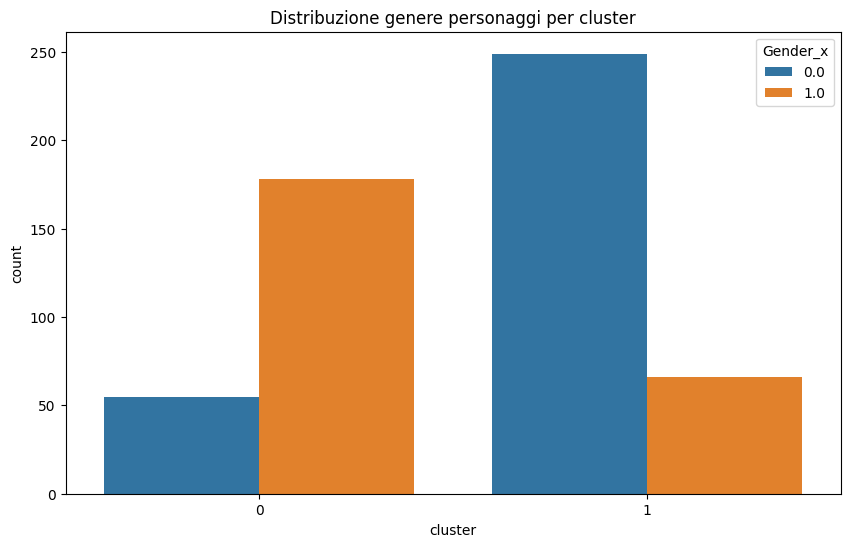

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df_merged, x='cluster', hue='Gender_x')
plt.title("Distribuzione genere personaggi per cluster")
plt.show()

## Visualizzazione con nuove info

In [29]:
# Calcolo embeddings concatenati (agent/patient/mod/pos)
X = np.vstack(df_merged.progress_apply(mean_concat_embeddings, axis=1))


  0%|          | 0/548 [00:00<?, ?it/s]

In [30]:
# UMAP 3D
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', n_components=3, random_state=42)
X_umap = umap_reducer.fit_transform(X)

/data-lachesis/common/propp/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [31]:
# Clustering HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean')
clusters = clusterer.fit_predict(X_umap)
df_merged['cluster'] = clusters

In [32]:
# Creiamo un DataFrame con le coordinate UMAP
df_umap = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_umap['char_name'] = df_merged['char_name_clean']
df_umap['file_name'] = df_merged['file_name_clean']
df_umap['type'] = df_merged['type']
df_umap['cluster'] = df_merged['cluster']
df_umap['Gender'] = df_merged['Gender_x']
df_umap['author_gender'] = df_merged['author_gender']

In [33]:
fig = px.scatter_3d(
    df_umap,
    x='UMAP1', y='UMAP2', z='UMAP3',
    color='author_gender',  # oppure 'author_gender'
    symbol='cluster',
    hover_data=['char_name', 'file_name', 'Gender', 'author_gender']
)
fig.show()

### Visualizzazione in 2d

In [34]:
# Calcolo embeddings concatenati (agent/patient/mod/pos)
X = np.vstack(df_merged.progress_apply(mean_concat_embeddings, axis=1))

  0%|          | 0/548 [00:00<?, ?it/s]

In [35]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

/data-lachesis/common/propp/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [36]:
import pandas as pd

df_umap = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Gender'] = df_merged['Gender_x']
df_umap['author_gender'] = df_merged['author_gender']
df_umap['char_name'] = df_merged['char_name_clean']
df_umap['file_name'] = df_merged['file_name_clean']
df_umap['type'] = df_merged['type']
df_umap['cluster'] = df_merged['cluster']

In [37]:
df_umap['Gender_label'] = df_umap['Gender'].map({0: 'Male', 1: 'Female'})
df_umap['author_gender_label'] = df_umap['author_gender'].map({0: 'Male', 1: 'Female'})
df_umap['type_label'] = df_umap['type'].map({0: 'Adult', 1: 'Child'})

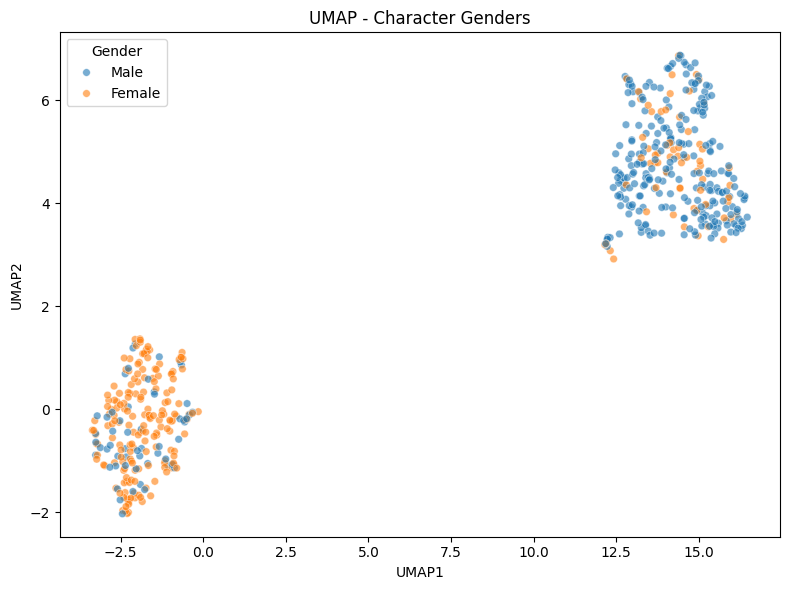

In [38]:
# per genere
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_umap,
    x='UMAP1',
    y='UMAP2',
    hue='Gender_label',
    hue_order=['Male', 'Female'],
    alpha=0.6,
    s=30
)

plt.title("UMAP - Character Genders")
plt.legend(title="Gender")
plt.tight_layout()

plt.savefig("umap_gender.png", dpi=300)
plt.show()

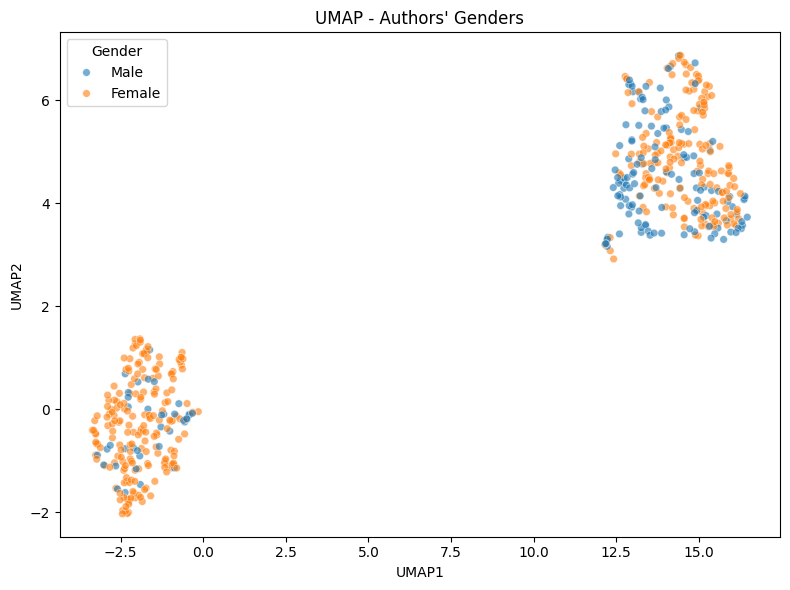

In [39]:
# per genere dell'autore
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_umap,
    x='UMAP1',
    y='UMAP2',
    hue='author_gender_label',
    hue_order=['Male', 'Female'],
    alpha=0.6,
    s=30
)

plt.title("UMAP - Authors' Genders")
plt.legend(title="Gender")
plt.tight_layout()

plt.savefig("umap_gender.png", dpi=300)
plt.show()

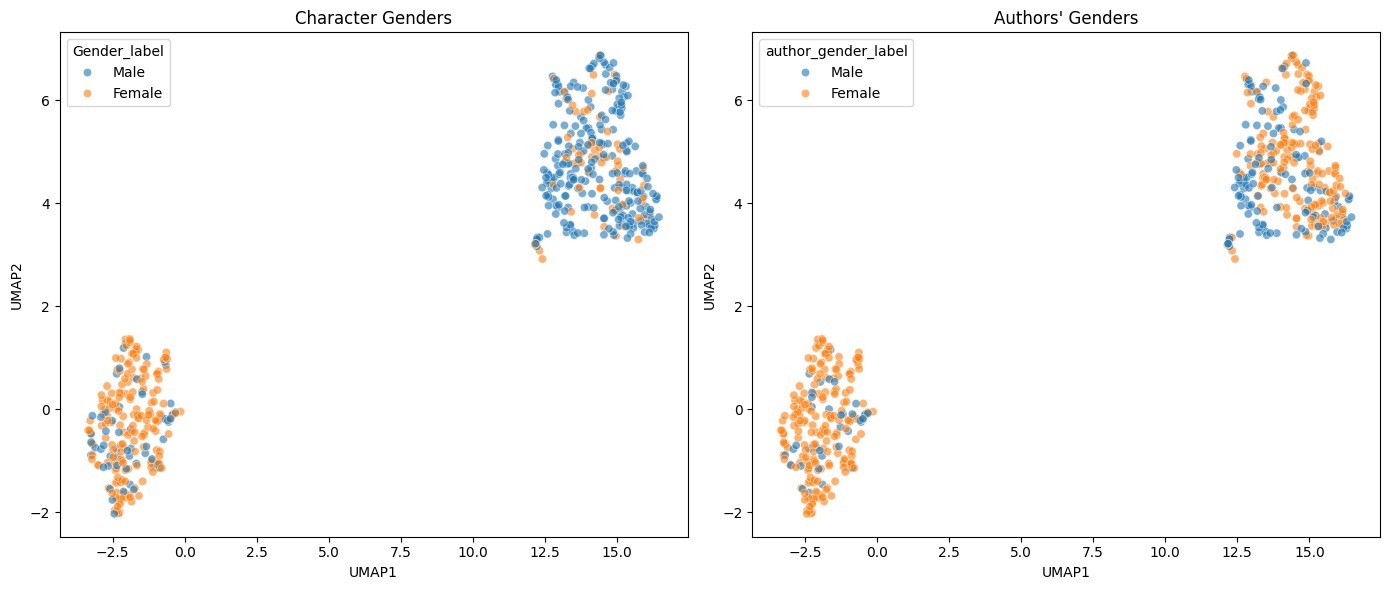

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='Gender_label', hue_order=['Male', 'Female'], ax=axes[0], alpha=0.6)
axes[0].set_title("Character Genders")

sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='author_gender_label', hue_order=['Male', 'Female'], ax=axes[1], alpha=0.6)
axes[1].set_title("Authors' Genders")

plt.tight_layout()
plt.savefig("umap_comparison.png", dpi=300)
plt.show()

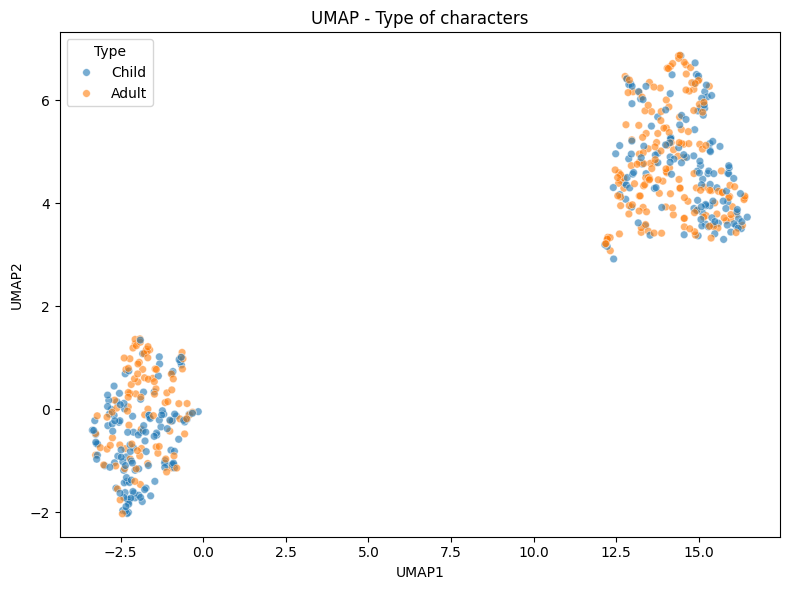

In [41]:
# per tipo
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_umap,
    x='UMAP1',
    y='UMAP2',
    hue='type_label',
    alpha=0.6,
    s=30
)

plt.title("UMAP - Type of characters")
plt.legend(title="Type")
plt.tight_layout()

plt.savefig("umap_gender.png", dpi=300)
plt.show()

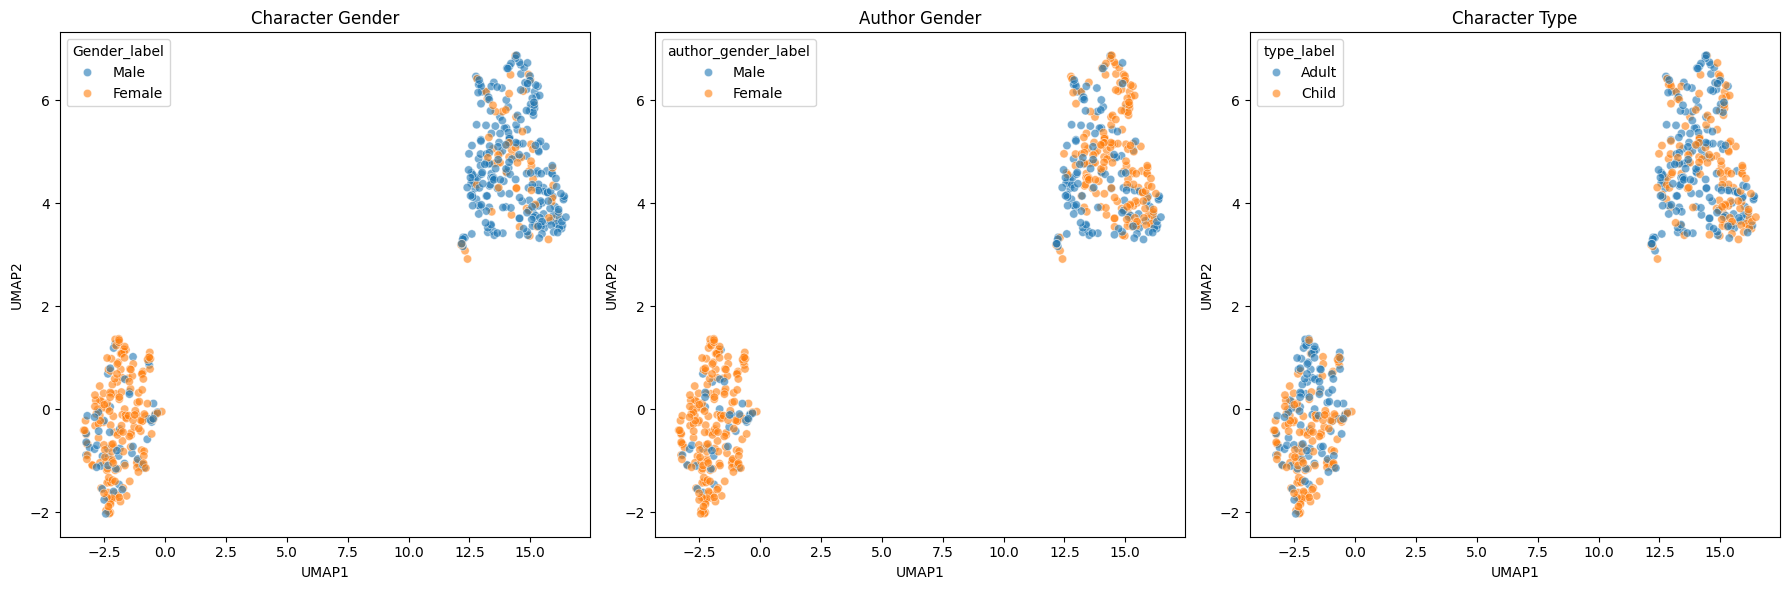

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))  # ← da 2 a 3

# 1️⃣ Character Gender
sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='Gender_label',
    hue_order=['Male', 'Female'],
    ax=axes[0],
    alpha=0.6
)
axes[0].set_title("Character Gender")

# 2️⃣ Author Gender
sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='author_gender_label',
    hue_order=['Male', 'Female'],
    ax=axes[1],
    alpha=0.6
)
axes[1].set_title("Author Gender")

# 3️⃣ Type (Adult vs Child)
sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='type_label',
    hue_order=['Adult', 'Child'],
    ax=axes[2],
    alpha=0.6
)
axes[2].set_title("Character Type")

plt.tight_layout()
plt.savefig("umap_comparison_3.png", dpi=300)
plt.show()

Riflessione: le donne (in numero maggiore nel cluster di sinistra) tendono a differenziare maggiormente i tratti tra bambini e adulti (due sottocluster). Inoltre, tendono a scrivere personaggi femminili più simili tra loro.

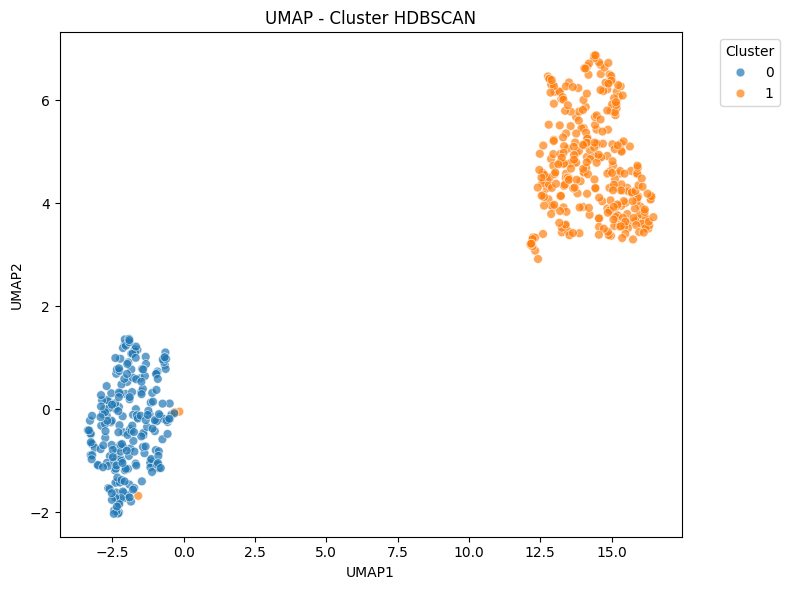

In [43]:
# Plot: cluster vs struttura UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='cluster',
    palette='tab10',   # colori distinti
    alpha=0.7,
    s=40
)

plt.title("UMAP - Cluster HDBSCAN")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig("/data-lachesis/common/propp/DeniseAtzori/Results/umap_clusters.png", dpi=300)
plt.show()

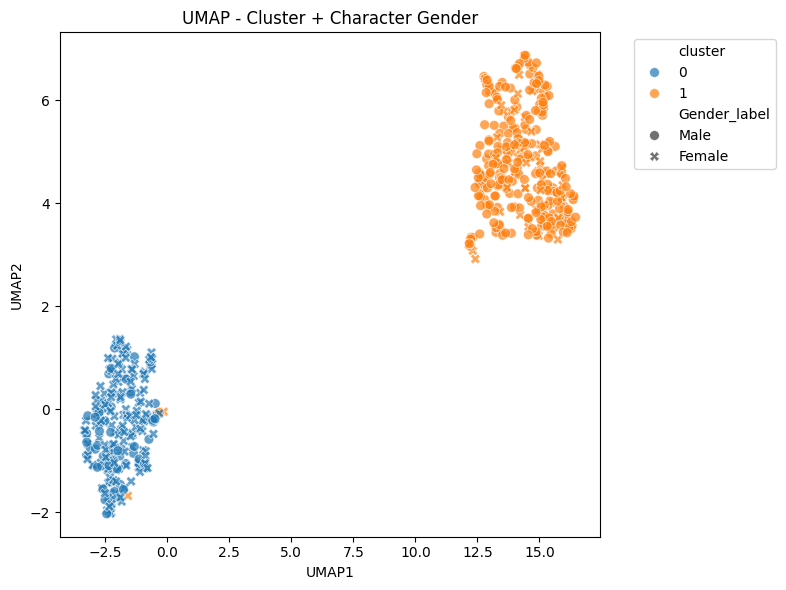

In [44]:
# Cluster + Gender (colore + forma)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='cluster',                 # colore = cluster
    style='Gender_label',          # forma = genere
    palette='tab10',
    alpha=0.7,
    s=50
)

plt.title("UMAP - Cluster + Character Gender")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig("umap_cluster_gender.png", dpi=300)
plt.show()

### Indagini sull'anno come possibile fattore di clusterizzazione

In [45]:
import re

# Funzione che estrae l'anno all'inizio del file_name
def extract_year(file_name):
    match = re.match(r'^(\d{4})', file_name)
    if match:
        return int(match.group(1))
    else:
        return None

# Applichiamo al dataframe
df_umap['year'] = df_umap['file_name'].apply(extract_year)

In [46]:
df_umap[['file_name', 'year']].head(10)

,file_name,year
0,1833_girardin-delphine-de_contes-d-une-vieille...,1833
1,1833_girardin-delphine-de_contes-d-une-vieille...,1833
2,1833_girardin-delphine-de_contes-d-une-vieille...,1833
3,1833_girardin-delphine-de_contes-d-une-vieille...,1833
4,1835_woillez-catherine_le-robinson-des-demoise...,1835
5,1835_woillez-catherine_le-robinson-des-demoise...,1835
6,1835_woillez-catherine_le-robinson-des-demoise...,1835
7,1835_woillez-catherine_le-robinson-des-demoise...,1835
8,1843_desnoyers-louis_les-aventures-de-jean-pau...,1843
9,1843_desnoyers-louis_les-aventures-de-jean-pau...,1843


Riflessione: i cluster sembrano dividersi abbastanza distintamente sia per author_gender che per Gender!

In [47]:
df_umap['decade'] = (df_umap['year'] // 10) * 10

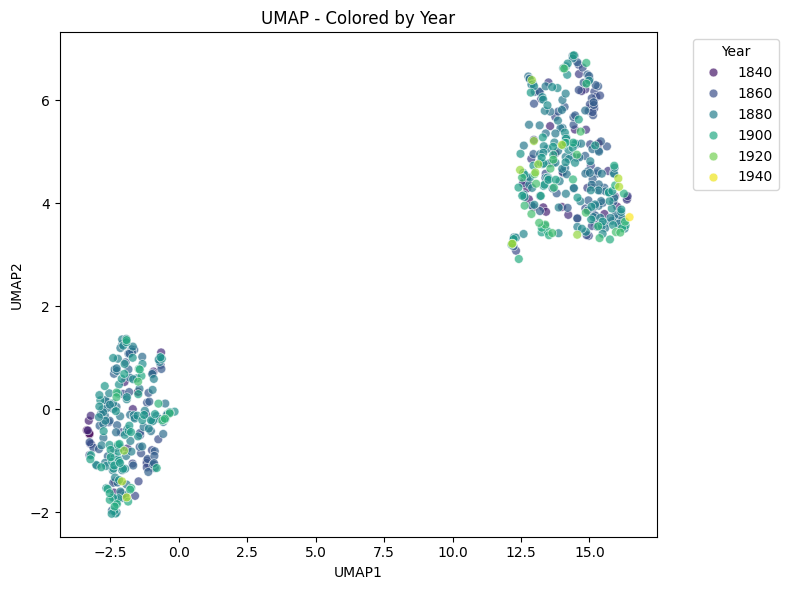

In [48]:
# cluster colorati in base all'anno

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='year',         # colore in base all'anno
    palette='viridis',  # scala continua
    alpha=0.7,
    s=40
)

plt.title("UMAP - Colored by Year")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("umap_year.png", dpi=300)
plt.show()

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

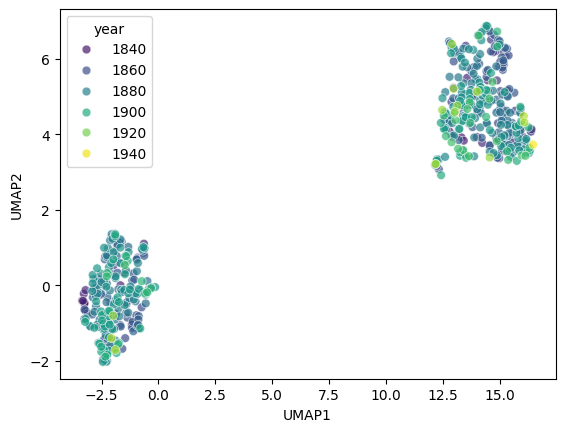

In [49]:
from matplotlib import colors

sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='year',
    palette='viridis',
    hue_norm=colors.Normalize(vmin=df_umap['year'].min(), vmax=df_umap['year'].max()),
    alpha=0.7,
    s=40
)

In [50]:
df_umap['decade'] = (df_umap['year'] // 10) * 10

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

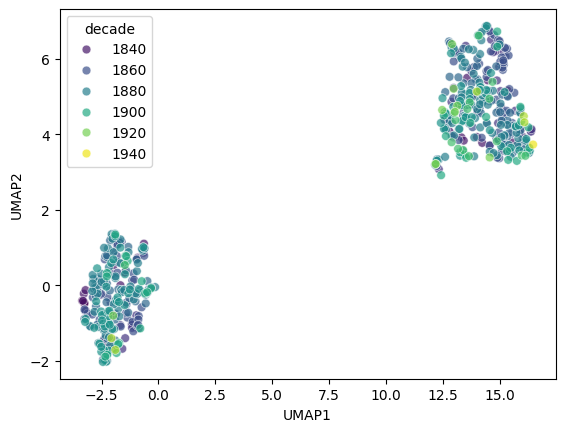

In [51]:
from matplotlib import colors

sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='decade',
    palette='viridis',
    hue_norm=colors.Normalize(vmin=df_umap['year'].min(), vmax=df_umap['year'].max()),
    alpha=0.7,
    s=40
)

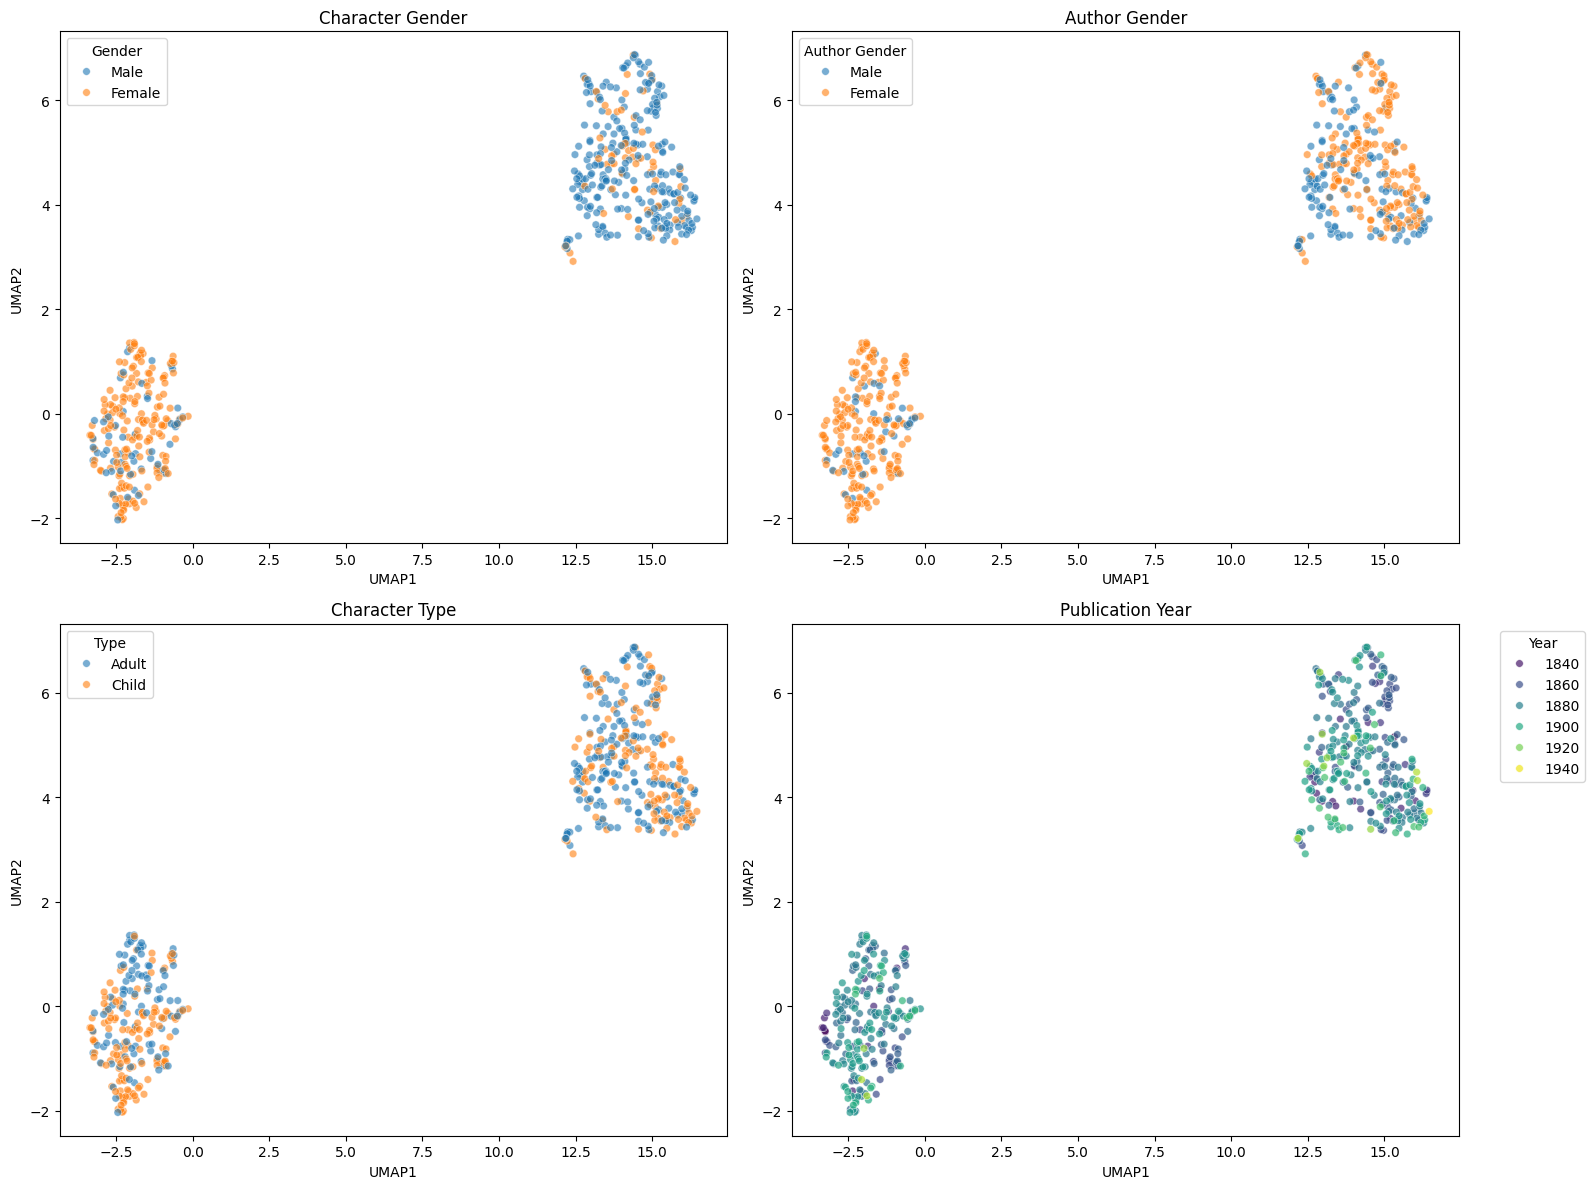

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors

fig, axes = plt.subplots(2, 2, figsize=(16,12))  # 2 righe x 2 colonne

# 1️⃣ Character Gender
sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='Gender_label',
    hue_order=['Male', 'Female'],
    ax=axes[0,0],
    alpha=0.6,
    s=30
)
axes[0,0].set_title("Character Gender")
axes[0,0].legend(title="Gender")

# 2️⃣ Author Gender
sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='author_gender_label',
    hue_order=['Male', 'Female'],
    ax=axes[0,1],
    alpha=0.6,
    s=30
)
axes[0,1].set_title("Author Gender")
axes[0,1].legend(title="Author Gender")

# 3️⃣ Character Type (Adult/Child)
sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='type_label',
    hue_order=['Adult', 'Child'],
    ax=axes[1,0],
    alpha=0.6,
    s=30
)
axes[1,0].set_title("Character Type")
axes[1,0].legend(title="Type")

# 4️⃣ Year
sns.scatterplot(
    data=df_umap,
    x='UMAP1', y='UMAP2',
    hue='year',
    palette='viridis',
    ax=axes[1,1],
    alpha=0.7,
    s=30,
    hue_norm=colors.Normalize(vmin=df_umap['year'].min(), vmax=df_umap['year'].max())
)
axes[1,1].set_title("Publication Year")
axes[1,1].legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("umap_comparison_4factors.png", dpi=300)
plt.show()

## Test chi-quadrato (χ²): cluster vs genere

verifica se:

- la distribuzione del genere è indipendente dai cluster
- oppure
- c’è una dipendenza statistica (cioè i cluster riflettono il genere)

In [86]:
# Cluster vs genere del personaggio
from scipy.stats import chi2_contingency

# Tabella di contingenza
contingency_gender = pd.crosstab(df_merged['cluster'], df_merged['Gender'])

print(contingency_gender)

# Test chi-quadrato
chi2, p, dof, expected = chi2_contingency(contingency_gender)

print("\nChi2:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

Gender     0    1
cluster          
0         38  189
1        136  172

Chi2: 43.517841365551575
p-value: 4.201116293949926e-11
degrees of freedom: 1


Riflessione: p-value << 0.05 relazione significativa!

In [87]:
# Cluster vs genere autore
contingency_author = pd.crosstab(df_merged['cluster'], df_merged['author_gender'])

chi2, p, dof, expected = chi2_contingency(contingency_author)

print("\nChi2 (author):", chi2)
print("p-value (author):", p)


Chi2 (author): 41.94994354338678
p-value (author): 9.364008713606769e-11


Riflessione: p-value << 0.05 relazione significativa!

### Effetto: quanto è forte la relazione? (Cramér’s V)

In [88]:
import numpy as np

def cramers_v(chi2, n, r, k):
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

# Per Gender
n = contingency_gender.sum().sum()
r, k = contingency_gender.shape

v_gender = cramers_v(chi2, n, r, k)
print("Cramér's V (Gender):", v_gender)

Cramér's V (Gender): 0.2800198375595757


Valore ~0.3 -> effetto medio

### Confronto osservato vs atteso

In [89]:
expected_df = pd.DataFrame(expected, 
                           index=contingency_gender.index, 
                           columns=contingency_gender.columns)

print("\nValori osservati:")
print(contingency_gender)

print("\nValori attesi (se indipendenti):")
print(expected_df)


Valori osservati:
Gender     0    1
cluster          
0         38  189
1        136  172

Valori attesi (se indipendenti):
Gender           0           1
cluster                       
0        71.947566  154.052434
1        98.052434  209.947566


In [92]:
residuals = (contingency_author - expected_df) / np.sqrt(expected_df)

print("\nResidui standardizzati:")
print(residuals)


Residui standardizzati:
author_gender       0.0       1.0
cluster                          
0             -4.120111  2.815676
1              3.529293 -2.411912


|valore| > 2 → differenza significativa

- positivo → più del previsto
- negativo → meno del previsto

👉 Esempio:

cluster 3 / femmine = +3.2 → forte sovra-rappresentazione

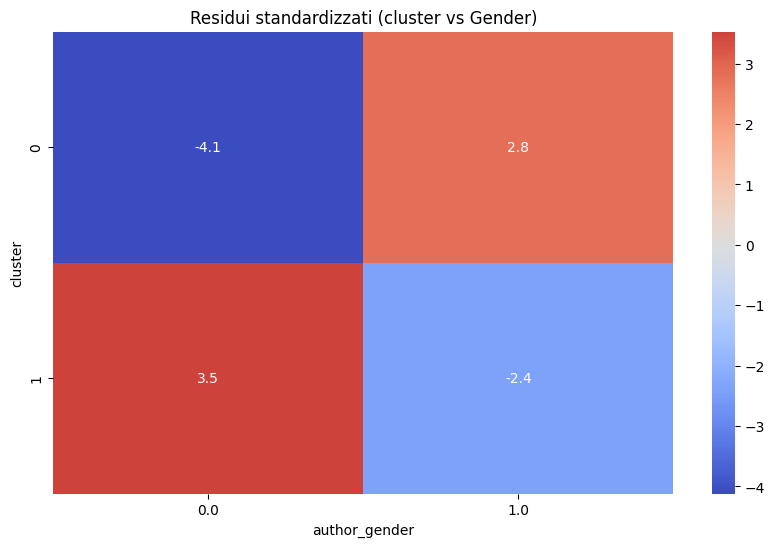

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(residuals, annot=True, cmap="coolwarm", center=0)
plt.title("Residui standardizzati (cluster vs Gender)")
plt.show()

# Features importance con Random Forest

Obiettivo: capire quali dimensioni degli embeddings sono più importanti in relazione al genere

In [94]:
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

tqdm.pandas()

# Assumo df_merged già pronto con Gender
df = df_merged.copy()

# Filtra righe valide
df = df[df['Gender'].notna()].reset_index(drop=True)

# Funzione embeddings
def mean_concat_embeddings(row):
    agent = row['agent_embeddings'].mean(dim=0).numpy() if len(row['agent_embeddings']) > 0 else np.zeros(row['agent_embeddings'].shape[1])
    patient = row['patient_embeddings'].mean(dim=0).numpy() if len(row['patient_embeddings']) > 0 else np.zeros(row['patient_embeddings'].shape[1])
    mod = row['mod_embeddings'].mean(dim=0).numpy() if len(row['mod_embeddings']) > 0 else np.zeros(row['mod_embeddings'].shape[1])
    pos = row['pos_embeddings'].mean(dim=0).numpy() if len(row['pos_embeddings']) > 0 else np.zeros(row['pos_embeddings'].shape[1])
    return np.concatenate([agent, patient, mod, pos])

print("Calcolo embeddings...")
X = np.vstack(df.progress_apply(mean_concat_embeddings, axis=1))

y = df['Gender'].values  # target

Calcolo embeddings...


  0%|          | 0/535 [00:00<?, ?it/s]

In [95]:
# addestramento Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [105]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from tqdm.auto import tqdm
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, test_idx in tqdm(cv.split(X, y), total=5, desc="CV Random Forest"):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)

print("\nCross-validation accuracy:", np.mean(scores))
print("Std:", np.std(scores))

CV Random Forest:   0%|          | 0/5 [00:00<?, ?it/s]


Cross-validation accuracy: 0.6579439252336448
Std: 0.022585132660924438


In [106]:
df['Gender'].value_counts(normalize=True)

Gender
1    0.674766
0    0.325234
Name: proportion, dtype: float64

In [ ]:
#features importance
importances = rf.feature_importances_

# Ordina per importanza
indices = np.argsort(importances)[::-1]

# Top 20 dimensioni
top_k = 20
print("Top feature più importanti:\n")

for i in range(top_k):
    idx = indices[i]
    print(f"{i+1}. Feature {idx} - importance: {importances[idx]:.6f}")

Top feature più importanti:

1. Feature 2171 - importance: 0.003458
2. Feature 2792 - importance: 0.003356
3. Feature 2121 - importance: 0.002384
4. Feature 2509 - importance: 0.002377
5. Feature 3034 - importance: 0.002214
6. Feature 2954 - importance: 0.002183
7. Feature 2643 - importance: 0.002090
8. Feature 2247 - importance: 0.002066
9. Feature 2915 - importance: 0.002029
10. Feature 2490 - importance: 0.001875
11. Feature 2766 - importance: 0.001784
12. Feature 2635 - importance: 0.001687
13. Feature 2464 - importance: 0.001607
14. Feature 2932 - importance: 0.001561
15. Feature 2645 - importance: 0.001531
16. Feature 304 - importance: 0.001505
17. Feature 2896 - importance: 0.001496
18. Feature 2820 - importance: 0.001495
19. Feature 3068 - importance: 0.001433
20. Feature 2569 - importance: 0.001413


In [98]:
# separazione per tipo (agent, patient etc)
D = df.iloc[0]['agent_embeddings'].shape[1]

def get_feature_type(idx):
    if idx < D:
        return "agent"
    elif idx < 2*D:
        return "patient"
    elif idx < 3*D:
        return "mod"
    else:
        return "pos"

print("\nTop feature con tipo:\n")

for i in range(top_k):
    idx = indices[i]
    print(f"{i+1}. Feature {idx} ({get_feature_type(idx)}) - importance: {importances[idx]:.6f}")


Top feature con tipo:

1. Feature 2171 (mod) - importance: 0.003458
2. Feature 2792 (mod) - importance: 0.003356
3. Feature 2121 (mod) - importance: 0.002384
4. Feature 2509 (mod) - importance: 0.002377
5. Feature 3034 (mod) - importance: 0.002214
6. Feature 2954 (mod) - importance: 0.002183
7. Feature 2643 (mod) - importance: 0.002090
8. Feature 2247 (mod) - importance: 0.002066
9. Feature 2915 (mod) - importance: 0.002029
10. Feature 2490 (mod) - importance: 0.001875
11. Feature 2766 (mod) - importance: 0.001784
12. Feature 2635 (mod) - importance: 0.001687
13. Feature 2464 (mod) - importance: 0.001607
14. Feature 2932 (mod) - importance: 0.001561
15. Feature 2645 (mod) - importance: 0.001531
16. Feature 304 (agent) - importance: 0.001505
17. Feature 2896 (mod) - importance: 0.001496
18. Feature 2820 (mod) - importance: 0.001495
19. Feature 3068 (mod) - importance: 0.001433
20. Feature 2569 (mod) - importance: 0.001413


In [99]:
# insight aggregato
importance_by_type = {
    "agent": 0,
    "patient": 0,
    "mod": 0,
    "pos": 0
}

for i, imp in enumerate(importances):
    importance_by_type[get_feature_type(i)] += imp

print("\nImportanza aggregata per tipo:\n")
for k, v in importance_by_type.items():
    print(f"{k}: {v:.4f}")


Importanza aggregata per tipo:

agent: 0.2124
patient: 0.2299
mod: 0.3253
pos: 0.2324


In [100]:
# visualizzazione
importance_by_type = {
    "agent": 0,
    "patient": 0,
    "mod": 0,
    "pos": 0
}

for i, imp in enumerate(importances):
    importance_by_type[get_feature_type(i)] += imp

print("\nImportanza aggregata per tipo:\n")
for k, v in importance_by_type.items():
    print(f"{k}: {v:.4f}")


Importanza aggregata per tipo:

agent: 0.2124
patient: 0.2299
mod: 0.3253
pos: 0.2324


Riflessione: sembrano essere i modificatori a influenzare maggiormente le differenze di genere!

Esploro i personaggi più “estremi” su quelle dimensioni

In [103]:
# collegare embeddings e lemmi
top_feature = indices[0]

# valori della feature
values = X[:, top_feature]

# top personaggi
top_idx = np.argsort(values)[-10:]

for i in top_idx:
    print(df.iloc[i]['char_name_clean'], df.iloc[i]['file_name_clean'])
    print("Mod lemmas:", df.iloc[i]['mod_lemmas'][:10])
    print()

dorothée 1893_marie-delorme_les-filles-du-clown
Mod lemmas: ['vieux', 'joli', 'fille', 'brun', 'pauvre', 'vieux', 'vieux', 'vieux', 'vieux', 'vieux']

dorothée 1868_gouraud-julie_l-enfant-du-guide
Mod lemmas: ['bon', 'oreille', 'bon', 'bon', 'bon', 'ami', 'fier', 'bon', 'excellent', 'cher']

ninie 1863_farrenc-cesarie_la-jalousie
Mod lemmas: ['brave', 'fille', 'bon', 'vieux', 'vieux', 'pauvre', 'vieux', 'pauvre', 'malheureux', 'jaloux']

robert 1867_houssaye-arsene_la-pantoufle-de-cendrillon-ou-suzanne-aux-coquelicots
Mod lemmas: ['pauvre', 'bon', 'vieux', 'invisible', 'bon']

sœur joséfa 1900_chabrier-rieder-charlotte_les-epreuves-de-charlotte
Mod lemmas: ['tout', 'religieux', 'heureux', 'sûr', 'bon', 'malheureux', 'sûr', 'content', 'bon', 'content']

mme bonbeck 1863_segur-comtesse-de_les-deux-nigauds
Mod lemmas: ['riche', 'seul', 'furieux', 'brave', 'femme', 'sec', 'vigoureux', 'vieux', 'ravir', 'méchant']

mme de rosbourg 1858_segur-comtesse-de_les-petites-filles-modeles
Mod lemmas